# CNN – Working on MNIST Dataset

This simple notebook demonstrates a basic **Convolutional Neural Network (CNN)** using the MNIST handwritten digit dataset.

**Topics covered:** loading data, visualization, preprocessing, CNN architecture, training, evaluation, and prediction.

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

## 2. Load the MNIST Dataset

MNIST contains grayscale images of handwritten digits from **0 to 9**. Each image is 28 × 28 pixels.

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## 3. Display Sample Images

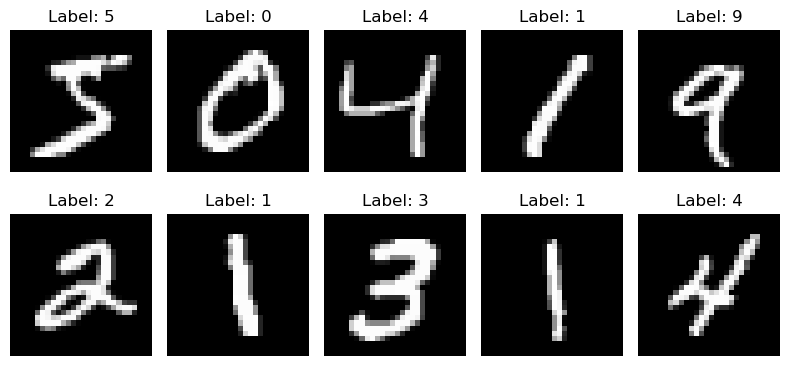

In [3]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Preprocess the Images

Pixel values range from 0 to 255. We scale them to 0–1 and add a channel dimension because CNNs expect image data in the form `(height, width, channels)`.

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("After preprocessing:", X_train.shape)

After preprocessing: (60000, 28, 28, 1)


## 5. Build a Simple CNN

- **Conv2D:** extracts image features such as edges and shapes.
- **MaxPooling2D:** reduces the spatial size of feature maps.
- **Flatten:** converts feature maps into a 1D vector.
- **Dense:** performs classification.
- **Softmax:** produces probabilities for digits 0–9.

In [5]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 7. Train the CNN

Five epochs are used for a simple demonstration.

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.9406 - loss: 0.1933 - val_accuracy: 0.9810 - val_loss: 0.0641
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9836 - loss: 0.0544 - val_accuracy: 0.9880 - val_loss: 0.0438
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9880 - loss: 0.0385 - val_accuracy: 0.9867 - val_loss: 0.0440
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9912 - loss: 0.0291 - val_accuracy: 0.9900 - val_loss: 0.0348
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.9926 - loss: 0.0231 - val_accuracy: 0.9868 - val_loss: 0.0487


## 8. Evaluate the Model

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.04506727308034897
Test Accuracy: 0.9857000112533569


## 9. Plot Training and Validation Accuracy

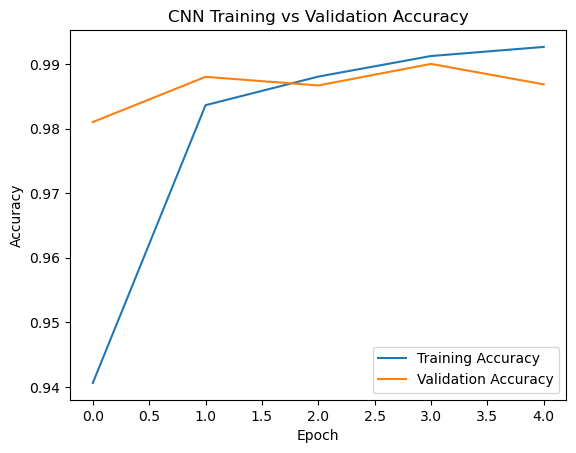

In [9]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

## 10. Make Predictions

The model returns probabilities for all 10 classes. `argmax()` selects the class with the highest probability.

In [10]:
predictions = model.predict(X_test[:10], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

print("Actual labels:   ", y_test[:10])
print("Predicted labels:", predicted_labels)

Actual labels:    [7 2 1 0 4 1 4 9 5 9]
Predicted labels: [7 2 1 0 4 1 4 9 5 9]


## 11. Visualize Predictions

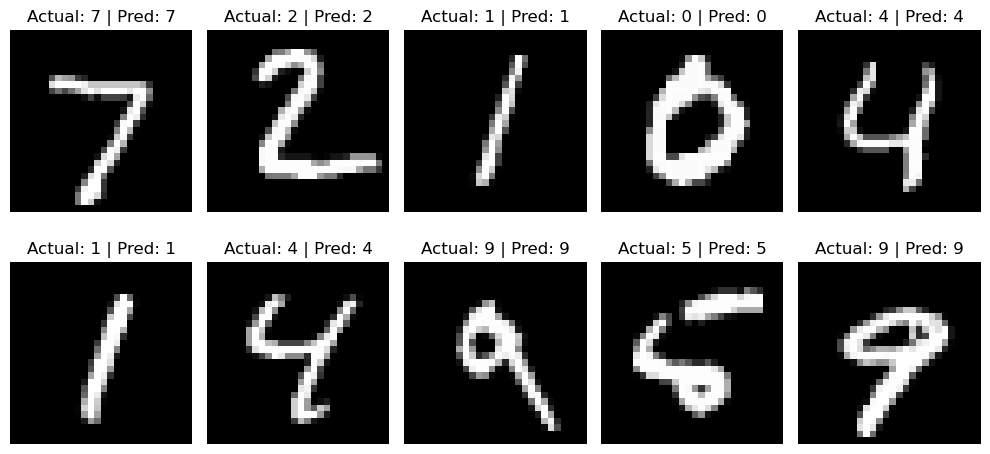

In [11]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.title(f"Actual: {y_test[i]} | Pred: {predicted_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 12. CNN Workflow Summary

**Image → Convolution → Feature Extraction → Pooling → Flatten → Dense → Softmax → Predicted Digit**

### Key points
- MNIST images are 28 × 28 grayscale images.
- CNN automatically learns useful image features.
- Convolution layers detect patterns such as edges and shapes.
- Pooling reduces spatial dimensions.
- Dense layers perform final classification.
- Softmax produces probabilities for digits 0–9.